# Parameter Information
1. So    :   initial value, that will be the last value of the historical data
2. dt    :   time increment, 1 month in our case. It is determined by the frequency of the historical data.For example, if the historical data is daily, dt should be 1/30 (1 month = 30 days). But it should be consistent with T.
3. T     :   length of the prediction time horizon, how many time points to predict. It should be consistent with dt. For example, if dt is 1 month and we want to predict for 6 months, T should be 6.
4. N     :   number of time points in the prediction time horizon, it is calculated by T/dt. For example, if T is 6 months and dt is 1 month, N should be 6. It is the number of time points within our prediction time horizon which should be consistent with our historical data in terms of time increment magnitude.
5. t     :   array for time points in the prediction time horizon [1, 2, 3, .. , N]. This is an array where we show the time progression in our model. It is like a time ticker where we measure time by counting the number of time points elapsed.
6. mu    :  Mean change in daily crime counts over the selected historical period. It is the average change in the historical data. It is calculated by taking the difference between each consecutive data point, summing them up and dividing by the number of data points. We will then use mu in our drift component calculation. It will have an effect on the long-term movement of the daliy number of crimes
7. sigma :   standard deviation of historical data (number of crimes per day). sigma will contribute by scaling the magnitude of random shock so that the small fluctuations occur in accordance with the historical volatility of the data.
8. b     :   array for brownian increments. Here array b, for each corresponding prediction time point, stores a random number coming from the standard normal distribution. These random numbers will add the random shocks. b is the random shock being applied to the data at a time point when predicting the data of the NEXT time point. So, suppose, at time point 3, the daily number of crimes is S_3. When predicting time point 4, b(4) is applied to S_3 as the random shock.
9. W     :   array for brownian path and it determines how the daily number of crimes fluctuate from beginning time point (So) to some other time point t. It means that it includes the effects of all the random shocks since the beginning of the prediction time horizon. It is the total effect of randomness incorporated into So(initial stock price) until the specific time point we are concerned with. So, suppose, we are predicting time point 4, we need to apply all the random shocks up-to and including time point 4 to So. Therefore, instead of b(4), we use W(4) which is the cumulative sum of array b elements with index less than or equal to 4.

Source : https://medium.com/data-science/simulating-stock-prices-in-python-using-geometric-brownian-motion-8dfd6e8c6b18


## Import Data and Libraries

In [2]:
from random import seed

import folium
from folium.plugins import MarkerCluster
import calendar
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
import numpy as np
from sklearn.model_selection import train_test_split, KFold,GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
import geopandas as gpd
import plotly.express as px

In [3]:
# Fájl elérési útja
csv_path = 'data/Number_of_crimes_per_day.csv'

# Beolvasás
df = pd.read_csv(csv_path)

In [4]:
# Create a new dataframe which contains data only for first district
df1 = df[df['District'] == 1].copy()
df1 = df1.drop(columns=['count', 'Number_of_days_in_month', 'District'])

In [5]:
# The historical data will be the data from 2001 to 2024
historical_data = df1[df1['Year'].between(2001, 2024)]
# We will predict to 2025
prediction_data = df1[df1['Year'] == 2025].copy()
prediction_data["Month"] = prediction_data["Month"].astype(int)
prediction_data = prediction_data[prediction_data['Month'].between(1, 8)]
prediction_data.reset_index(drop=True, inplace=True)
validation_data = prediction_data['Number of Crimes Per Day'].copy()
prediction_data = prediction_data.drop(columns=['Number of Crimes Per Day'])


In [6]:
#set seed for reproducibility
seed =np.random.seed(42)


## Geometric Brownian Motion Model Implementation - Define Parameters

In [7]:
# Initial value, that will be the last value of the historical data
So = historical_data['Number of Crimes Per Day'].values[-1]
So


np.float64(35.774193548387096)

In [8]:
# Time increment, 1 month in our case
dt = 1 # 1 month
# Length of the prediction time horizon, how many time points to predict
T = 8  # 8 monthss
# Number of time points in the prediction time horizon
N = int(T / dt)  # 9 time points
# Array for time points in the prediction time horizon [1, 2, 3, .. , N]
t = np.arange(1, int(N) + 1)
print(t)

[1 2 3 4 5 6 7 8]


In [9]:
# Calculate mu- first we calculate the rate of relative daily changes in the historical data ((actual data - previous data)/previous data)
Rate_of_dailychange = np.diff(historical_data['Number of Crimes Per Day'].values) / historical_data['Number of Crimes Per Day'].values[:-1]
print(Rate_of_dailychange)
#Calculate mu
mu = np.mean(Rate_of_dailychange)
mu


[-4.29782082e-02  7.30837790e-02 -6.35658915e-02 -5.78936125e-02
  5.44217687e-02  9.91935484e-02 -8.80410858e-03 -1.17345176e-01
  6.41806899e-02  3.65904912e-02 -1.50089958e-01  3.59570662e-01
  2.26503759e-02 -1.19933830e-01  1.21710526e-01 -1.46627566e-02
  4.90520282e-02  1.18734895e-02  2.49221184e-03  1.86451212e-03
 -9.30521092e-03 -1.09016907e-01 -1.46883126e-02  3.20970043e-02
  1.83877974e-02  3.28397276e-02 -2.70915462e-02 -2.01021993e-02
  1.01699977e-01 -1.34912526e-02 -2.79010780e-02 -3.07023266e-02
  4.31154381e-02 -9.13333333e-02 -2.08979244e-02 -3.69833212e-02
 -5.17760698e-02  1.77693192e-01 -8.02427512e-02  2.19941349e-02
  1.19320899e-01  6.19525742e-02  7.24200362e-03 -9.66846415e-02
  3.40710606e-02  3.39961514e-02 -9.30521092e-02  9.91792066e-02
 -1.44323940e-01  2.68557478e-02  3.18696884e-02  6.45161290e-02
  6.13152805e-02 -1.40331693e-02 -3.69685767e-02  6.22734058e-03
 -2.84430503e-02 -1.06653578e-01 -2.71299846e-02 -3.68975904e-02
 -1.66424662e-02  6.78100

np.float64(0.005560059471798539)

In [10]:
# calculate sigma
sigma = np.std(Rate_of_dailychange)
sigma

np.float64(0.11365597802997726)

In [11]:
# array for brownian increments
scen_size = 2
rng = np.random.default_rng(seed=42)

b = {
    str(scen): rng.normal(0, 1, int(N))
    for scen in range(1, scen_size + 1)
}

print(b)

{'1': array([ 0.30471708, -1.03998411,  0.7504512 ,  0.94056472, -1.95103519,
       -1.30217951,  0.1278404 , -0.31624259]), '2': array([-0.01680116, -0.85304393,  0.87939797,  0.77779194,  0.0660307 ,
        1.12724121,  0.46750934, -0.85929246])}


In [12]:
# array for brownian path
W = {str(scen): b[str(scen)].cumsum() for scen in range(1, scen_size + 1)}
print(W)

{'1': array([ 0.30471708, -0.73526703,  0.01518417,  0.95574889, -0.9952863 ,
       -2.29746581, -2.16962541, -2.485868  ]), '2': array([-0.01680116, -0.86984509,  0.00955289,  0.78734483,  0.85337552,
        1.98061673,  2.44812607,  1.58883361])}


## Geometric Brownian Motion Model Implementation - Prediction

* We will call longer-term trends as **Drift** and shorter-term fluctuations as **Diffusion**.

* At time point \( k-1 \), the value must follow the longer-term trend (drift) while being exposed to a random shock (diffusion) to predict the value at time point \( k \). Thus, both components of the Geometric Brownian Motion (GBM) are applied.
* **Drift component**: drift = mu - 0.5 *sigma^2 -> S_k = S_(k-1) * exp(drift)
    * mu and sigma are calculated from the historical data. They are constants.
    * So the drift component is a constant.

* **Diffusion component**: diffusion = sigma*b(k)
    * b(k) is a random number coming from the standard normal distribution.
    * So the diffusion component is a random number scaled by sigma.
    * Also, the diffusion component makes it possible to create different prediction scenarios.
* The two components are combined as follows: S_k = S_(k-1) * exp(drift + diffusion)
* S_K = S_(k-2) * exp(drift + diffusion(k-1)) * exp(drift + diffusion(k)) ->
S_k = S_0 * prod(i=1 to k) exp(drift + diffusion(i))
* S_k = S_0 * exp((mu-0.5*sigma^2)*k + sum(i=1 to k) sigma*b(i))
    * S(k) from So by adding the combined effect of k many drifts and the cumulative diffusion up to k
    * The cumulative diffusion up to k is represented by W(k) which is the cumulative sum of b(i) where i goes from 1 to k.
    * Therefore, S_k = S_0 * exp((mu-0.5*sigma^2)*t_k + sigma*W(k))

In [13]:
# Calculate drift and diffusion components
drift = (mu - 0.5 * sigma**2) * t
print("drift:\n", drift)
diffusion = {str(scen): sigma * W[str(scen)] for scen in range(1, scen_size + 1)}
print("diffusion:\n", diffusion)


drift:
 [-0.00089878 -0.00179756 -0.00269634 -0.00359512 -0.00449391 -0.00539269
 -0.00629147 -0.00719025]
diffusion:
 {'1': array([ 0.03463292, -0.08356749,  0.00172577,  0.10862657, -0.11312024,
       -0.26112072, -0.2465909 , -0.28253376]), '2': array([-0.00190955, -0.09886309,  0.00108574,  0.08948645,  0.09699123,
        0.22510893,  0.27824416,  0.18058044])}


In [14]:
 # Predict the daily number of crimes for each time point in the prediction time horizon
S = np.array([So * np.exp(drift + diffusion[str(scen)]) for scen in range(1, scen_size + 1)])
print(S)
print("Predicted daily number of crimes:\n", S)




[[37.00159128 32.84704306 35.73948896 39.73602601 31.80465424 27.40466823
  27.78078006 26.7759146 ]
 [35.67386863 32.34845065 35.71662199 38.9827057  39.24107801 44.56474284
  46.95452018 42.54732437]]
Predicted daily number of crimes:
 [[37.00159128 32.84704306 35.73948896 39.73602601 31.80465424 27.40466823
  27.78078006 26.7759146 ]
 [35.67386863 32.34845065 35.71662199 38.9827057  39.24107801 44.56474284
  46.95452018 42.54732437]]


In [15]:
# Convert the prediction results to a DataFrame for better visualization and add the corresponding months and years
predicted_df = pd.DataFrame(S.T, columns=[f'Scenario {scen}' for scen in range(1, scen_size + 1)])
predicted_df['Month'] = prediction_data['Month']
predicted_df['Year'] = prediction_data['Year']
predicted_df = predicted_df[['Year', 'Month'] + [f'Scenario {i}' for i in range(1, scen_size + 1)]]
predicted_df = predicted_df.round(2)
predicted_df.to_csv('docs/Szakdolgozat docs/Results/predicted_df.csv',header=["Év", "Hónap", "Szcenárió 1", "Szcenárió 2"], index=False)


In [16]:
predicted_df[['Year', 'Month', 'Scenario 1', 'Scenario 2']]

,Year,Month,Scenario 1,Scenario 2
0,2025,1,37.00,35.67
1,2025,2,32.85,32.35
2,2025,3,35.74,35.72
3,2025,4,39.74,38.98
4,2025,5,31.80,39.24
5,2025,6,27.40,44.56
6,2025,7,27.78,46.95
7,2025,8,26.78,42.55


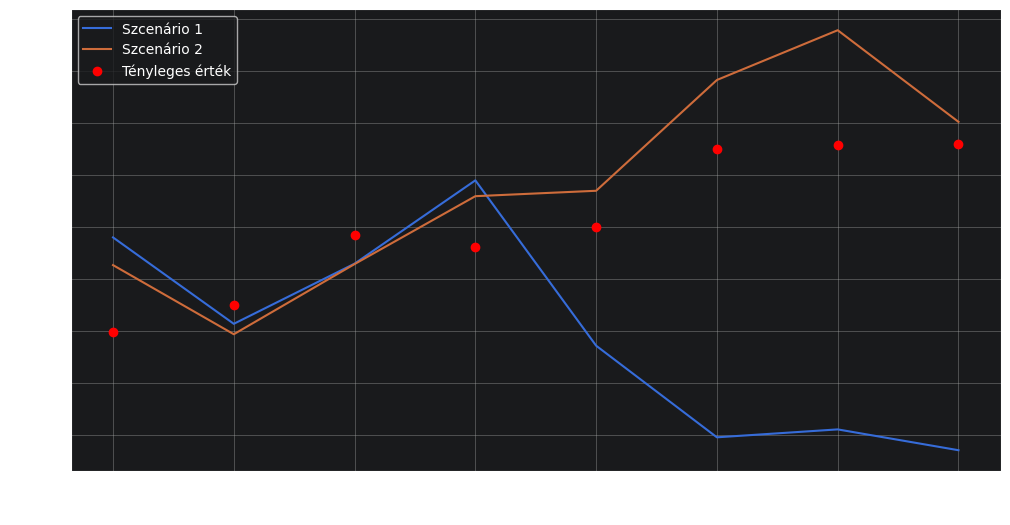

In [17]:
# Visualize the prediction results
plt.figure(figsize=(12, 6), facecolor='white')

for scen in range(1, scen_size + 1):
    plt.plot(predicted_df['Month'], predicted_df[f'Scenario {scen}'], label=f'Szcenário {scen}')
plt.scatter(predicted_df['Month'], validation_data, color='red', label='Tényleges érték', zorder=5)
plt.xlabel('Hónapok')
plt.ylabel('Napi átlagos bűneset')
plt.legend()
plt.grid()

plt.savefig('docs/Szakdolgozat docs/Images/Results_img/prediction_plot.png')

In [18]:
# Calculate RMSE for each scenario
rmse_values = {f'Scenario {scen}': np.sqrt(mean_squared_error(validation_data, predicted_df[f'Scenario {scen}'])) for scen in range(1, scen_size + 1)}
print("RMSE values for each scenario:\n", rmse_values)

RMSE values for each scenario:
 {'Scenario 1': np.float64(9.092700378196207), 'Scenario 2': np.float64(2.8633129978337024)}


## Analysis and Visualization of Prediction Results

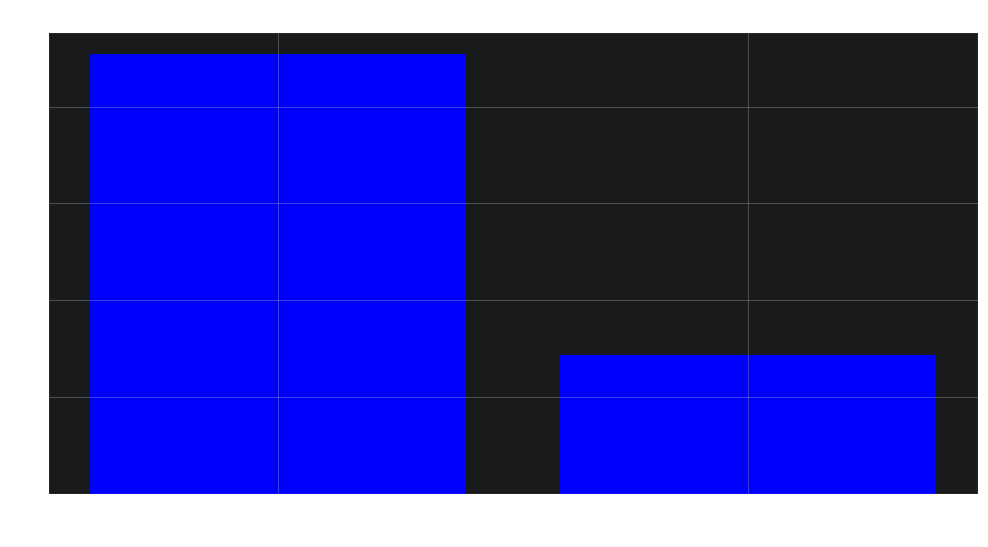

In [19]:
# Visualize the RMSE values for each scenario
plt.figure(figsize=(12, 6), facecolor='white')
plt.bar(range(1, scen_size + 1), rmse_values.values(), color='blue')
plt.title('RMSE értékek szcenáriónként')
plt.xlabel('Szcenárió')
plt.ylabel('RMSE')
plt.xticks(range(1, scen_size + 1))
plt.grid()
plt.savefig('docs/Szakdolgozat docs/Images/Results_img/rmse_plot.png')
plt.show()

# Calculate the prediction for all districts

Feladat pontosítása:
- Ugyanazt a GBM-alapú lépésrendszert futtasd le minden District-re külön-külön.
- Mentsd el kerületenként a 2025-ös havi előrejelzéseket (több szcenárióval) és az ezekhez tartozó RMSE értékeket.
- Készíts összefoglaló DataFrame-et: kerület, év, hónap, szcenáriók, RMSE-k.

In [20]:
# Az összes kerület GBM előrejelzése és RMSE számítása kerületenként
districts = sorted(df['District'].dropna().astype(int).unique())
all_predictions = []
all_rmses = []

for d in districts:
    ddf = df[df['District'] == d].copy()
    ddf["Month"] = ddf["Month"].astype(int)
    ddf = ddf.drop(columns=['count', 'Number_of_days_in_month', 'District'])
    hist = ddf[ddf['Year'].between(2001, 2024)]
    pred_df = ddf[ddf['Year'] == 2025].drop(columns=['Number of Crimes Per Day'])
    pred_df['Month'] = pred_df['Month'].astype(int)
    pred_df = pred_df[pred_df['Month'].between(1, 8)].reset_index(drop=True)
    valid = ddf[
        (ddf['Year'] == 2025) &
        (ddf['Month'].between(1, 8))
    ]['Number of Crimes Per Day'].reset_index(drop=True)


    if hist.empty or pred_df.empty or len(pred_df) != 8:
        continue

    So_d = hist['Number of Crimes Per Day'].values[-1]
    Rate_d = np.diff(hist['Number of Crimes Per Day'].values) / hist['Number of Crimes Per Day'].values[:-1]
    mu_d = float(np.mean(Rate_d)) if Rate_d.size else 0.0
    sigma_d = float(np.std(Rate_d)) if Rate_d.size else 0.0

    dt_d = dt
    T_d = T
    N_d = int(T_d / dt_d)
    t_d = np.arange(1, N_d + 1)

    scen_n = scen_size
    rng = np.random.default_rng(seed=42)
    b_d = {str(s): rng.normal(0, 1, N_d) for s in range(1, scen_n + 1)}
    W_d = {str(s): b_d[str(s)].cumsum() for s in range(1, scen_n + 1)}

    drift_d = (mu_d - 0.5 * sigma_d ** 2) * t_d
    diffusion_d = {str(s): sigma_d * W_d[str(s)] for s in range(1, scen_n + 1)}
    S_d = np.array([So_d * np.exp(drift_d + diffusion_d[str(s)]) for s in range(1, scen_n + 1)])

    pred_d = pd.DataFrame(S_d.T, columns=[f'Scenario {s}' for s in range(1, scen_n + 1)])
    pred_d['Month'] = pred_df['Month'].values
    pred_d['Year'] = pred_df['Year'].values
    pred_d['District'] = d
    pred_d = pred_d[['District', 'Year', 'Month'] + [f'Scenario {i}' for i in range(1, scen_n + 1)]]
    all_predictions.append(pred_d)

    rmse_d = {f'Scenario {s}': float(np.sqrt(mean_squared_error(valid, pred_d[f'Scenario {s}']))) for s in
              range(1, scen_n + 1)}
    rmse_row = {'District': d, **rmse_d}
    all_rmses.append(rmse_row)

predictions_by_district = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()
rmse_by_district = pd.DataFrame(all_rmses)

predictions_by_district

,District,Year,Month,Scenario 1,Scenario 2
0,1,2025,1,37.001591,35.673869
1,1,2025,2,32.847043,32.348451
2,1,2025,3,35.739489,35.716622
3,1,2025,4,39.736026,38.982706
4,1,2025,5,31.804654,39.241078
...,...,...,...,...,...
171,25,2025,4,35.174250,34.762893
172,25,2025,5,30.610387,34.829909
173,25,2025,6,27.873876,37.582279
174,25,2025,7,28.048455,38.725708


In [21]:
rmse_by_district


,District,Scenario 1,Scenario 2
0,1,9.092097,2.866174
1,2,7.403783,2.056870
2,3,6.985541,2.043821
3,4,7.567431,1.704018
4,5,4.961380,1.731285
5,6,8.139740,1.748820
6,7,6.444410,1.394154
7,8,5.520956,2.649412
8,9,5.832249,1.915283
9,10,4.704075,1.890304


In [22]:
# Use that scenario which has the lowest RMSE for each district
#best_scenarios = rmse_by_district.set_index('District').idxmin(axis=1)
#best_scenarios
best_scenarios = (
    rmse_by_district
    .set_index('District')
    .idxmin(axis=1)                       # pd.Series: index=District, value=Scenario neve
    .rename('BestScenario')
    .reset_index()
)
# Show the best scenario predictions for each district and each month
best_predictions = (
    predictions_by_district
    .melt(id_vars=['District', 'Year', 'Month'], var_name='Scenario', value_name='Predicted Crimes')
    .merge(best_scenarios, on='District', how='inner')     # hozzárendeljük a legjobb scenariót kerületenként
)
best_predictions = best_predictions[best_predictions['Scenario'] == best_predictions['BestScenario']] \
    .drop(columns=['BestScenario']) \
    .sort_values(['District', 'Year', 'Month']) \
    .reset_index(drop=True)

best_predictions
#Add actual values to best_predictions for comparison
actual_values = df[(df['Year'] == 2025)][['District', 'Month', 'Number of Crimes Per Day']]
best_predictions = best_predictions.merge(actual_values, on=['District', 'Month'], how='left')
best_predictions.rename(columns={'Number of Crimes Per Day': 'Actual Crimes'}, inplace=True)
best_predictions["Error"] = (
    best_predictions["Actual Crimes"] - best_predictions["Predicted Crimes"]
)

best_predictions["RMSE"] = np.sqrt(best_predictions["Error"] ** 2)



best_predictions

,District,Year,Month,Scenario,Predicted Crimes,Actual Crimes,Error,RMSE
0,1,2025,1,Scenario 2,35.673869,32.451613,-3.222256,3.222256
1,1,2025,2,Scenario 2,32.348451,33.750000,1.401549,1.401549
2,1,2025,3,Scenario 2,35.716622,37.129032,1.412410,1.412410
3,1,2025,4,Scenario 2,38.982706,36.533333,-2.449372,2.449372
4,1,2025,5,Scenario 2,39.241078,37.483871,-1.757207,1.757207
...,...,...,...,...,...,...,...,...
171,25,2025,4,Scenario 1,35.174250,33.066667,-2.107583,2.107583
172,25,2025,5,Scenario 1,30.610387,31.000000,0.389613,0.389613
173,25,2025,6,Scenario 1,27.873876,31.633333,3.759458,3.759458
174,25,2025,7,Scenario 1,28.048455,33.806452,5.757997,5.757997


In [23]:
#calculate overall MAE, MAPE, RMSE for the best scenario predictions across all districts
overall_mae = np.mean(np.abs(best_predictions["Error"]))
overall_mape = np.mean(np.abs(best_predictions["Error"] / best_predictions["Actual Crimes"])) * 100
overall_rmse = np.sqrt(np.mean(best_predictions["Error"] ** 2))
overall_accuracy = 100 - overall_mape
overall_metrics = {
    "RMSE": overall_rmse,
    "MAE": overall_mae,
    "MAPE": overall_mape,
    "Accuracy": overall_accuracy,
}
overall_metrics= pd.DataFrame([overall_metrics])
overall_metrics = overall_metrics.round(2)
overall_metrics.to_csv('docs/Szakdolgozat docs/Results/overall_metrics.csv', index=False)
overall_metrics

,RMSE,MAE,MAPE,Accuracy
0,2.43,1.93,6.92,93.08


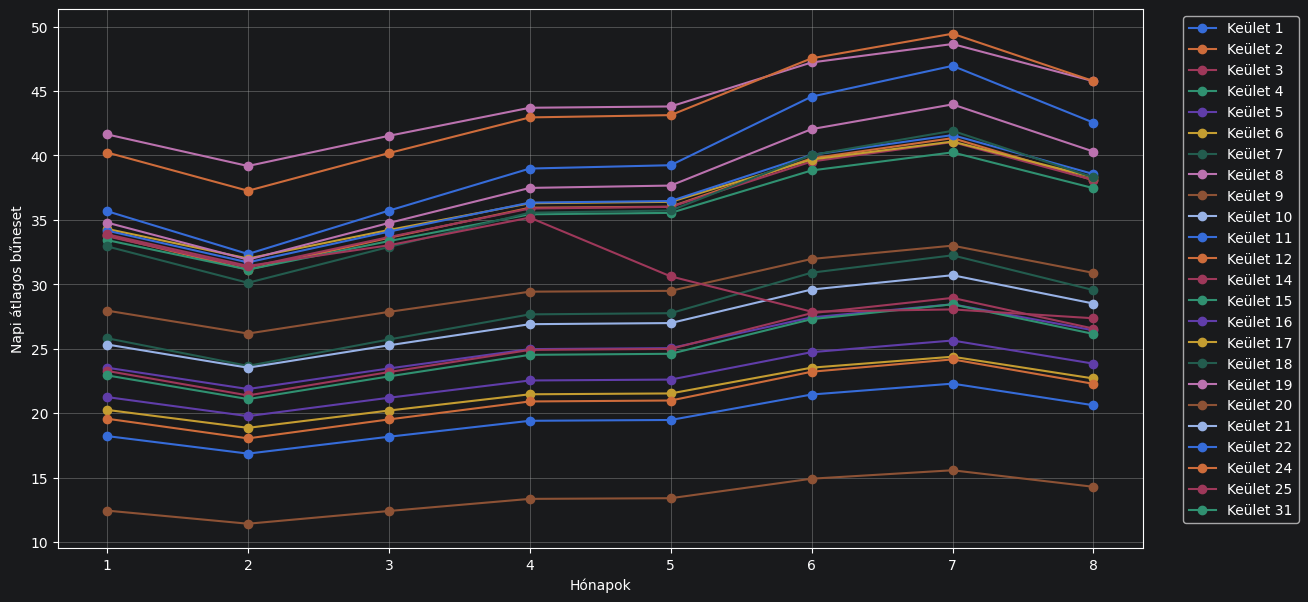

In [24]:
# Visualize the best scenario predictions for each district
plt.figure(figsize=(14, 7))
for d in districts:
    district_data = best_predictions[best_predictions['District'] == d]
    plt.plot(district_data['Month'], district_data['Predicted Crimes'], marker='o', label=f'Keület {d}')
plt.xlabel('Hónapok')
plt.ylabel('Napi átlagos bűneset')
plt.legend(bbox_to_anchor=(1.15, 1), loc="upper right")
plt.grid()
plt.savefig('docs/Szakdolgozat docs/Images/Results_img/best_scenario_predictions.png')
plt.show()

In [25]:
# Import geojson file for districts
districts_gdf = gpd.read_file("data/PoliceDistrictDec2012_20251008.geojson")
districts_gdf = districts_gdf.drop([':updated_at', ':created_at'], axis=1)
district_crimes = df['District'].value_counts().reset_index()
district_crimes.columns = ['District', 'Crime_Count']
district_crimes['District'] = district_crimes['District'].astype(int)
districts_gdf['dist_num'] = districts_gdf['dist_num'].astype(int)

In [33]:
dist_avg_error_gbm = {"District": [], "Error": []}

for dist in best_predictions["District"].unique():
    errors = best_predictions[best_predictions["District"] == dist]["Error"]
    avg_err = np.mean(errors)

    # Hozzáadjuk a listák VÉGÉHEZ
    dist_avg_error_gbm["District"].append(dist)
    dist_avg_error_gbm["Error"].append(avg_err)

df_avg_error_gbm = pd.DataFrame(dist_avg_error_gbm)


In [35]:
dist_avg_predict_gbm = {"District": [], "Predicted": []}
for dist in best_predictions["District"].unique():
    predict = best_predictions[best_predictions["District"] == dist]["Predicted Crimes"]
    avg_predict = np.mean(predict)
    dist_avg_predict_gbm["District"].append(dist)
    dist_avg_predict_gbm["Predicted"].append(avg_predict)

dist_avg_predict_gbm = pd.DataFrame(dist_avg_predict_gbm)

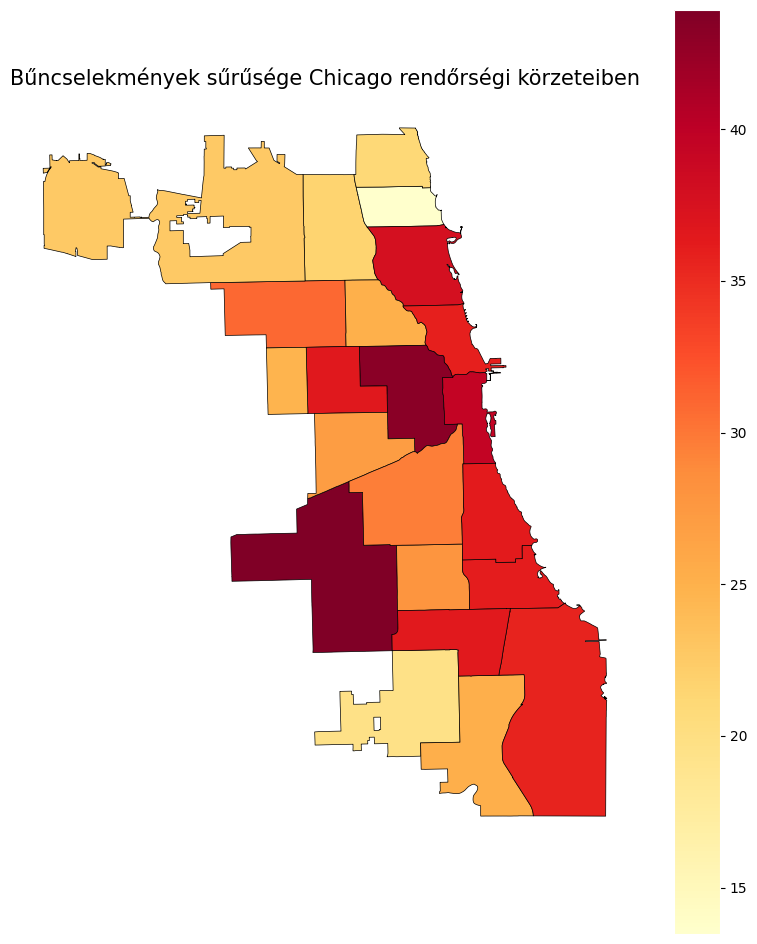

In [36]:
best_predictions_map = pd.merge(
    districts_gdf,
    dist_avg_predict_gbm,
    left_on='dist_num',
    right_on='District',
    how='inner')
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
fig.patch.set_facecolor('white')

# A 'column' határozza meg, mi alapján színezzen (pl. esetszám)
best_predictions_map.plot(column='Predicted',
               ax=ax,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black', # Kerületek határvonala
               linewidth=0.5)

ax.set_title('Bűncselekmények sűrűsége Chicago rendőrségi körzeteiben', fontsize=15, color='black')
ax.axis('off') # Leveszi a koordináta-tengelyeket, hogy térképnek tűnjön
cax = fig.axes[1]

# Feketére állítjuk a számokat (tick labels)
cax.tick_params(labelcolor='black', color='black')

plt.savefig('docs/Szakdolgozat docs/Images/Results_img/gbm_predicted_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

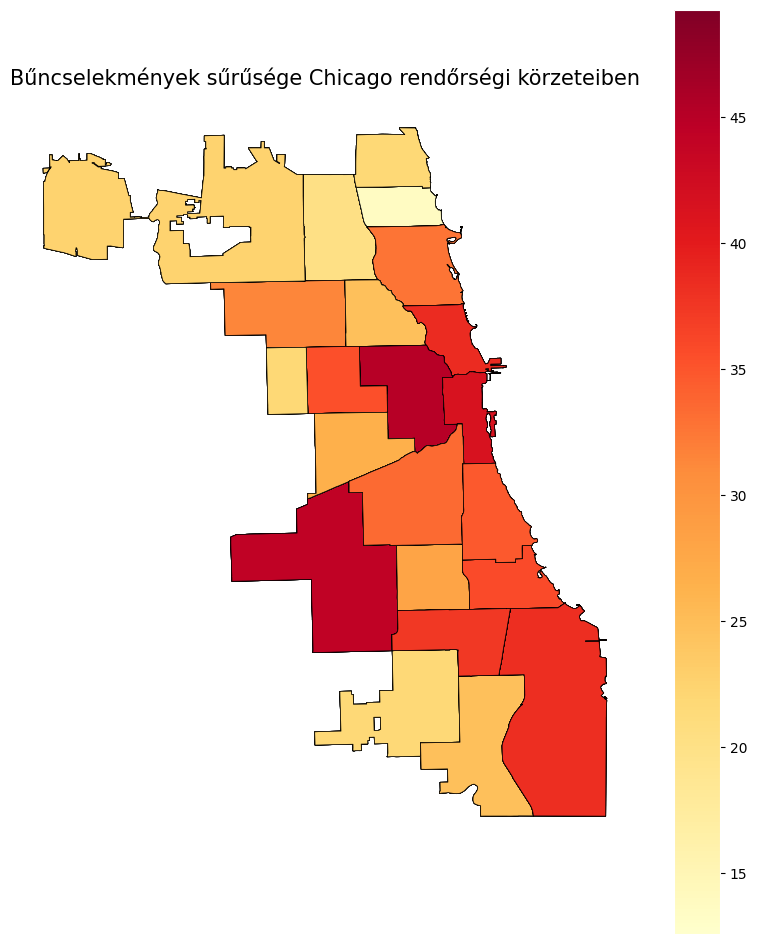

In [37]:
best_predictions_map = pd.merge(
    districts_gdf,
    best_predictions,
    left_on='dist_num',
    right_on='District',
    how='inner')
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
fig.patch.set_facecolor('white')

# A 'column' határozza meg, mi alapján színezzen (pl. esetszám)
best_predictions_map.plot(column='Actual Crimes',
               ax=ax,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black', # Kerületek határvonala
               linewidth=0.5)

ax.set_title('Bűncselekmények sűrűsége Chicago rendőrségi körzeteiben', fontsize=15, color='black')
ax.axis('off') # Leveszi a koordináta-tengelyeket, hogy térképnek tűnjön
cax = fig.axes[1]

# Feketére állítjuk a számokat (tick labels)
cax.tick_params(labelcolor='black', color='black')

plt.savefig('docs/Szakdolgozat docs/Images/Results_img/gbm_actual_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

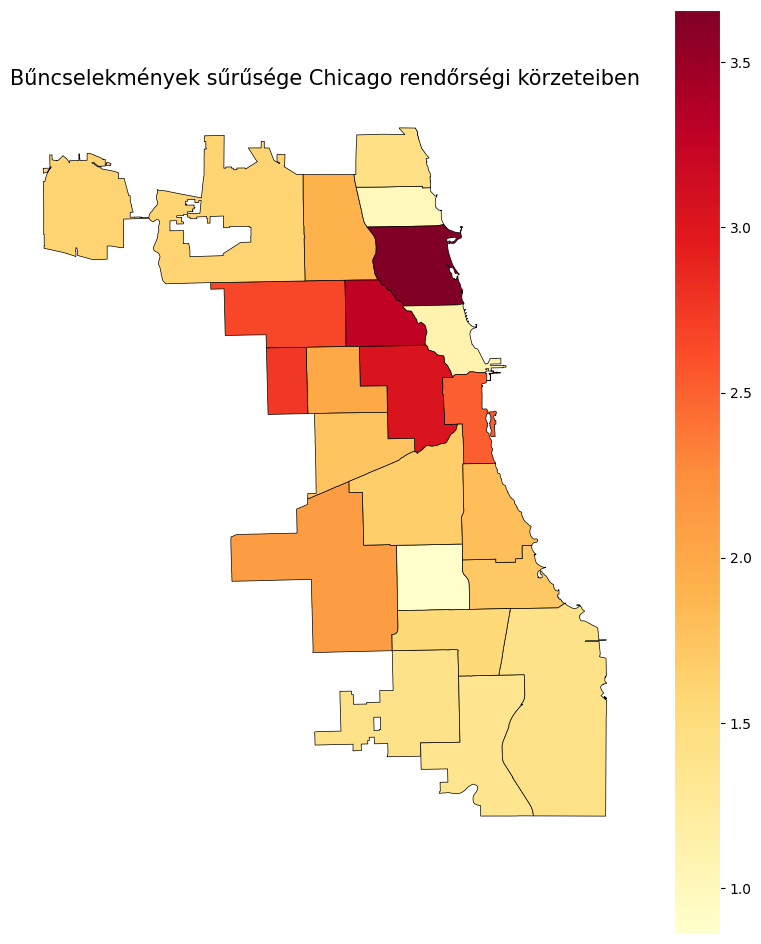

In [32]:
best_predictions_map = pd.merge(
    districts_gdf,
    df_avg_error_gbm,
    left_on='dist_num',
    right_on='District',
    how='inner')
best_predictions_map["Error"] = abs(best_predictions_map["Error"])
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
fig.patch.set_facecolor('white')

# A 'column' határozza meg, mi alapján színezzen (pl. esetszám)
best_predictions_map.plot(column='Error',
               ax=ax,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black', # Kerületek határvonala
               linewidth=0.5)

ax.set_title('Bűncselekmények sűrűsége Chicago rendőrségi körzeteiben', fontsize=15, color='black')
ax.axis('off') # Leveszi a koordináta-tengelyeket, hogy térképnek tűnjön
cax = fig.axes[1]

# Feketére állítjuk a számokat (tick labels)
cax.tick_params(labelcolor='black', color='black')

plt.savefig('docs/Szakdolgozat docs/Images/Results_img/gbm_difference_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [31]:
dist_avg_error = {"District": [], "Error": []}

for dist in best_predictions["District"].unique():
    errors = best_predictions[best_predictions["District"]==dist]["Error"]
    avg_err = np.mean(abs(errors))

    # Hozzáadjuk a listák VÉGÉHEZ
    dist_avg_error["District"].append(dist)
    dist_avg_error["Error"].append(avg_err)

df_avg_error_gbm = pd.DataFrame(dist_avg_error)